In [1]:
import pandas as pd
from scipy.io import mmread
import scipy.sparse
import scanpy as sc
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ranksums
from scipy import stats

In [2]:
scroot = '/work/users/k/r/kritis/single_cell/PRJNA679579'

In [3]:
X = mmread(f"{scroot}/GSE161824_A549_TP53.processed.matrix.mtx").tocsr()

In [4]:
# Load gene names and barcodes
genes = pd.read_csv(f"{scroot}/GSE161824_A549_TP53.processed.genes.csv", header=None)
barcodes = pd.read_csv(f"{scroot}/GSE161824_A549_TP53.processed.cells.csv", header=None)

In [5]:
import anndata as ad
adata = ad.AnnData(X)
adata.var_names = genes[0].values  # column 1 = gene symbols
adata.obs_names = barcodes[0].values

In [6]:
# Calculate basic QC metrics
sc.pp.calculate_qc_metrics(adata, inplace=True)

# Filter cells: min genes, max counts, max % mitochondrial
adata = adata[adata.obs['n_genes_by_counts'] > 200, :]
adata = adata[adata.obs['total_counts'] < 25000, :]

/nas/longleaf/home/kritis/.local/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/nas/longleaf/home/kritis/.local/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [7]:
sc.pp.filter_genes(adata, min_cells=10)

/nas/longleaf/home/kritis/.local/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:283: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["n_cells"] = number


In [8]:
barcodes_mut = pd.read_csv('/work/users/k/r/kritis/database_analysis/TP53_example/MDM2_barcodes.csv')

In [9]:
barcode_list = barcodes_mut['cell_barcode'].tolist()

In [10]:
adata.obs['mut'] = adata.obs_names.isin(barcode_list)
# Optional: make it clearer
adata.obs['mut'] = adata.obs['mut'].map({True: 'Target', False: 'Other'})

In [11]:
adata_target = adata[adata.obs['mut'] == 'Target'].copy()
adata_other = adata[adata.obs['mut'] == 'Other'].copy()

In [12]:
adata.obs['mut'].value_counts()

mut
Other     64248
Target    21530
Name: count, dtype: int64

In [14]:
sc.tl.rank_genes_groups(adata, groupby='mut', method='wilcoxon', 
                        groups=['Target'], reference='Other')

/nas/longleaf/home/kritis/.local/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


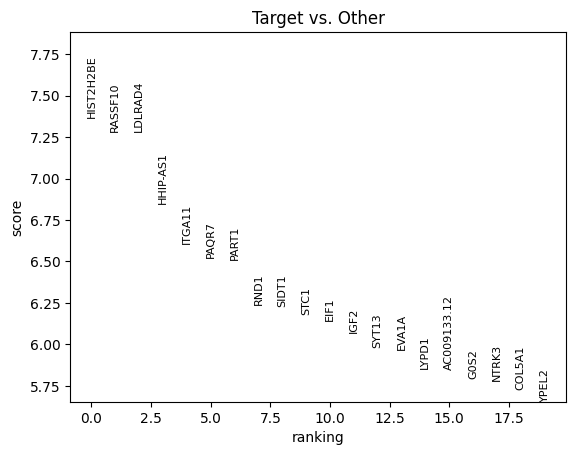

,Target_names,Target_scores,Target_logfoldchanges,Target_pvals_adj
0,HIST2H2BE,7.368357,NaN,3.020538e-11
1,RASSF10,7.282773,NaN,4.523190e-11
2,LDLRAD4,7.280499,-1.602722,4.523190e-11
3,HHIP-AS1,6.848704,NaN,8.292260e-10
4,ITGA11,6.609318,-1.747571,3.938175e-09


In [15]:
sc.pl.rank_genes_groups(adata, n_genes=20, sharey=False)

# Extract as a DataFrame
import pandas as pd
result = adata.uns['rank_genes_groups']
groups = result['names'].dtype.names
de_genes = pd.DataFrame(
    {group + '_' + key: result[key][group]
     for group in groups for key in ['names', 'scores', 'logfoldchanges', 'pvals_adj']}
)
de_genes.head()

In [23]:
de_genes[de_genes['Target_names']=='ADM']

,Target_names,Target_scores,Target_logfoldchanges,Target_pvals_adj
747,ADM,-0.358826,1.276977,0.839794


In [50]:
de2 = de_genes.dropna().sort_values('Target_logfoldchanges').reset_index(drop=True)

In [52]:
de2[de2['Target_names']=='ADM']

,Target_names,Target_scores,Target_logfoldchanges,Target_pvals_adj
456,ADM,-0.358826,1.276977,0.839794
